<font face="Times New Roman" size=5>
<div dir=rtl align="center">
<font face="Times New Roman" size=5>
In The Name of God
</font>
<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Communication Systems
</font>
<hr/>
<font color="#800080" size=5>
Assignment 3
<br>
</font>
<font size=5>
Instructor: Dr. Pakravan
<br>
</font>
<font size=4>
Fall 2025
<br>
</font>

<hr>
<br>
</font>
<font face="Times New Roman" size=4 align=center>
Feel free to ask your questions in Telegram : @YadollahiAlii

Email : ali.yadollahi81@sharif.edu
</font>
<br>
<hr>
</div></font>

Name = "Amitis Mirabedini"

StudentId = "402102562"

# Import Libraries

In [1]:
### add your libraries

## Question 1: 
## Signal Sampling and Reconstruction with Sinc Functions


In this part, we’ll delve into an essential concept in signal processing: **sampling and reconstructing signals using sinc interpolation**. The aim is to understand how signals can be sampled, reconstructed from discrete data points, and how the reconstruction is influenced by using an **ideal sinc function** versus a **limited sinc function**.

### Task 1.1 : Define Your Signal
 - Write a function $ f(t) $ to represent your continuous signal.  
 - Feel free to choose a signal that excites your curiosity—a sine wave, a square wave, or even your custom creation.

In [2]:
# Task 1.1
import numpy as np
def f(t, f0 = 5):
    return np.sin(2 * np.pi * f0 * t)

### Task 1.2 : Sample the Signal
- Create a function that takes the continuous signal and samples it at a specified **sampling rate**.  
- The function should output the sampled time points and the corresponding signal values.

In [3]:
# Task 1.2
def sample_signal(signal, fs, t_start, t_end):
    Ts = 1/fs
    t_samples = np.arange(t_start, t_end, Ts)
    x_samples = signal(t_samples)

    return t_samples, x_samples

### Task 1.3 : Reconstruct the Signal
- Implement two reconstruction functions:  
    - **Ideal Sinc Interpolation**: A perfect reconstruction using the standard sinc function.  
    - **Limited Sinc Interpolation**: A practical reconstruction with sinc pulses restricted in range.  
- Reconstruct the signal across the original time vector using both methods.


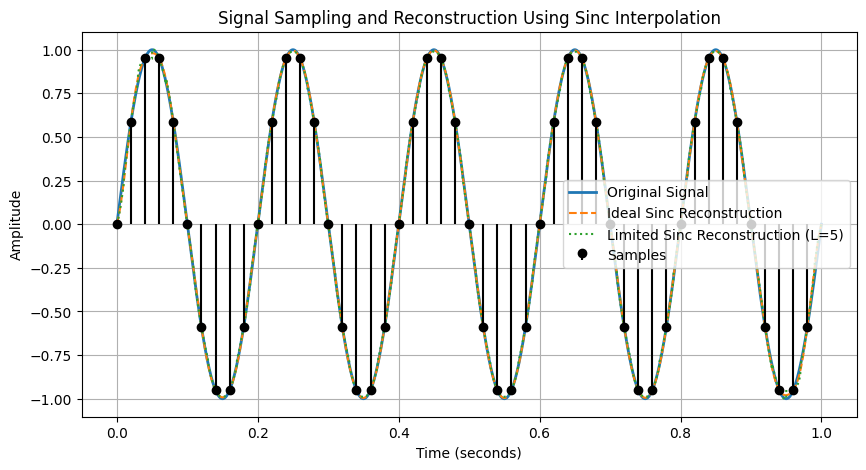

In [7]:
import matplotlib.pyplot as plt

def ideal_sinc(t, t_samples, x_samples, fs):
    x_reconstructed = np.zeros_like(t)

    for n in range(len(t_samples)):
        x_reconstructed += x_samples[n] * np.sinc(fs * (t - t_samples[n]))
    return x_reconstructed

def limited_sinc(t, t_samples, x_samples, fs, L = 5):
    x_reconstruced = np.zeros_like(t)
    Ts = 1 / fs
    for i, ti in enumerate(t):
        n0 = int(np.round(ti/Ts))
        n_min = max(n0 - L, 0)
        n_max = min(n0 + L + 1, len(t_samples))

        for n in range(n_min, n_max):
            x_reconstruced[i] += x_samples[n] * np.sinc(fs * (ti - t_samples[n]))

    
    return x_reconstruced


t_start = 0
t_end = 1
t = np.linspace(t_start, t_end, 5000)
x_original = f(t)

fs = 50
t_samples, x_samples = sample_signal(f, fs, t_start, t_end)


x_ideal = ideal_sinc(t, t_samples, x_samples, fs)
x_limited = limited_sinc(t, t_samples, x_samples, fs, L=5)




plt.figure(figsize=(10, 5))

# Original continuous signal
plt.plot(t, x_original, label="Original Signal", linewidth=2)

# Ideal sinc reconstruction
plt.plot(t, x_ideal, label="Ideal Sinc Reconstruction", linestyle="--")

# Limited sinc reconstruction
plt.plot(t, x_limited, label="Limited Sinc Reconstruction (L=5)", linestyle=":")

# Sampled points (stem plot)
plt.stem(t_samples, x_samples, linefmt='k-', markerfmt='ko', basefmt=" ", label="Samples")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Signal Sampling and Reconstruction Using Sinc Interpolation")
plt.legend()
plt.grid(True)

plt.show()


 




### Task 1.4 : Calculate Reconstruction Error
- Compute the **Mean Squared Error (MSE)** to measure the difference between the original and reconstructed signals.  
- Compare the errors for ideal and limited sinc interpolations. 

In [8]:
# Task 1.4
def mse_calc(x_true, x_reconstructed):
    return np.mean((x_true - x_reconstructed)**2)

mse_ideal = mse_calc(x_original, x_ideal)
mse_limited = mse_calc(x_original, x_limited)

print(f"Mean Squared Error (Ideal Sinc): {mse_ideal:.6f}")
print(f"Mean Squared Error (Limited Sinc, L=5): {mse_limited:.6f}")

Mean Squared Error (Ideal Sinc): 0.000124
Mean Squared Error (Limited Sinc, L=5): 0.000228


MSE is bigger in the Limited Sinc method than the Ideal Sinc method

### Task 1.5 : Visualize Your Work
Plot the following:  
- The original signal alongside the sampled points and reconstructed signals (for both ideal and limited sinc methods).  
- Individual sinc pulse contributions to the reconstruction process for both methods.

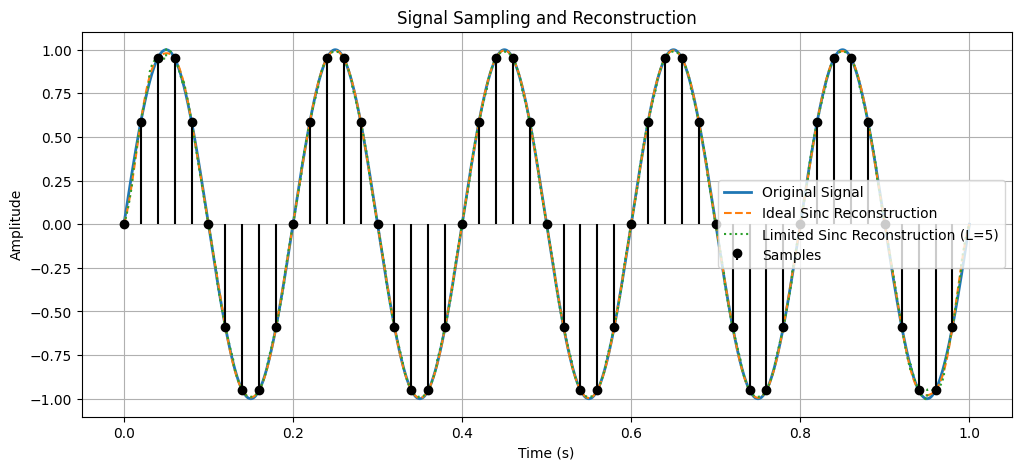

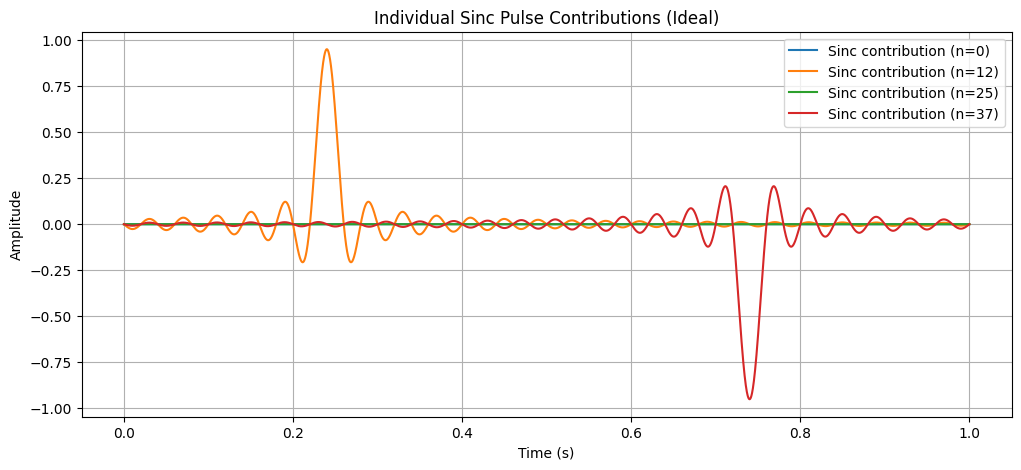

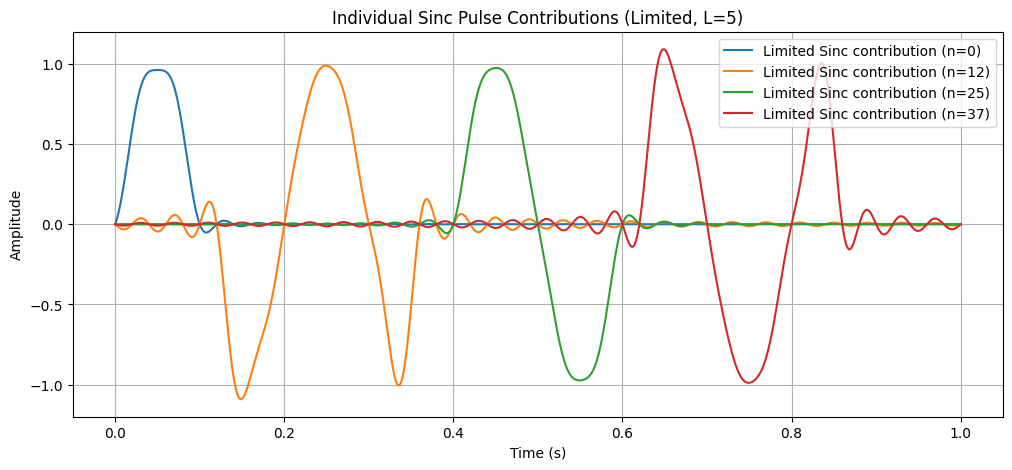

In [9]:
# Task 1.5
import matplotlib.pyplot as plt

# -----------------------------
# 1. Original signal + reconstructions + samples
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(t, x_original, label="Original Signal", linewidth=2)
plt.plot(t, x_ideal, '--', label="Ideal Sinc Reconstruction")
plt.plot(t, x_limited, ':', label="Limited Sinc Reconstruction (L=5)")
plt.stem(t_samples, x_samples, linefmt='k-', markerfmt='ko', basefmt=" ", label="Samples")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Signal Sampling and Reconstruction")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 2. Individual sinc pulse contributions
# -----------------------------
# Pick a few sample indices to visualize their contributions
sample_indices_to_plot = [0, len(t_samples)//4, len(t_samples)//2, 3*len(t_samples)//4]

# Ideal sinc contributions
plt.figure(figsize=(12, 5))
for n in sample_indices_to_plot:
    contribution = x_samples[n] * np.sinc(fs * (t - t_samples[n]))
    plt.plot(t, contribution, label=f"Sinc contribution (n={n})")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Individual Sinc Pulse Contributions (Ideal)")
plt.legend()
plt.grid(True)
plt.show()

# Limited sinc contributions
L = 5
plt.figure(figsize=(12, 5))
for n in sample_indices_to_plot:
    # Truncated range
    n_min = max(n - L, 0)
    n_max = min(n + L + 1, len(t_samples))
    contribution = np.zeros_like(t)
    for k in range(n_min, n_max):
        contribution += x_samples[k] * np.sinc(fs * (t - t_samples[k]))
    plt.plot(t, contribution, label=f"Limited Sinc contribution (n={n})")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Individual Sinc Pulse Contributions (Limited, L={L})")
plt.legend()
plt.grid(True)
plt.show()


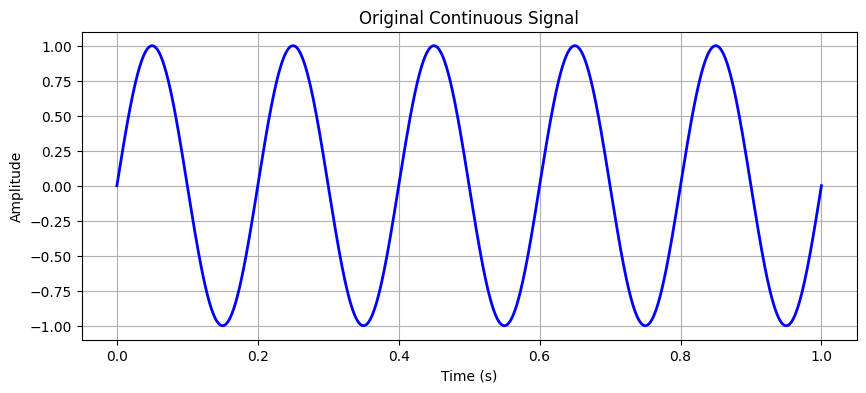

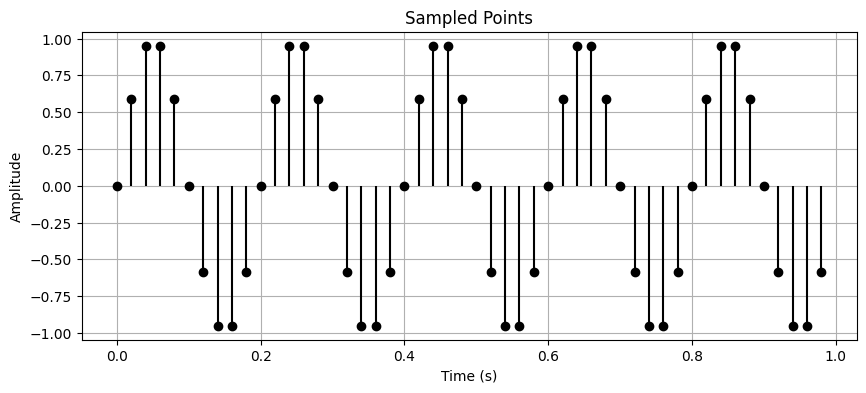

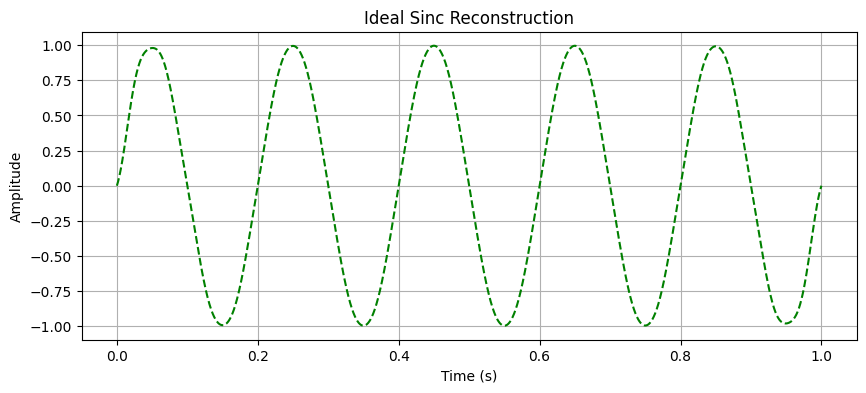

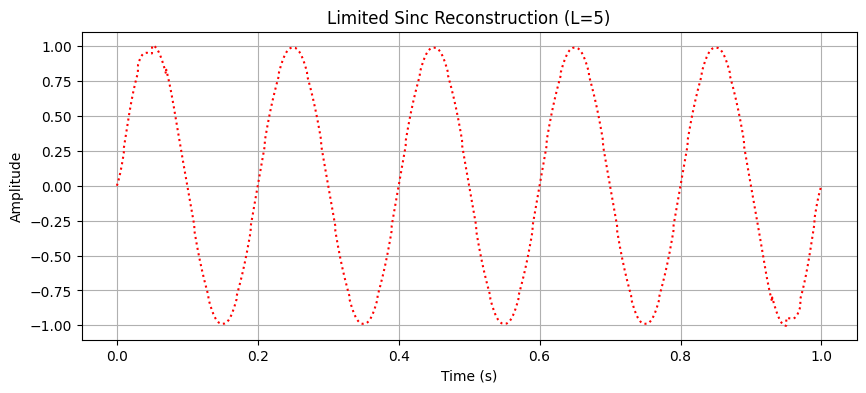

In [10]:
import matplotlib.pyplot as plt

# 1. Original signal
plt.figure(figsize=(10, 4))
plt.plot(t, x_original, color='blue', linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Original Continuous Signal")
plt.grid(True)
plt.show()

# 2. Sampled points
plt.figure(figsize=(10, 4))
plt.stem(t_samples, x_samples, linefmt='k-', markerfmt='ko', basefmt=" ")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Sampled Points")
plt.grid(True)
plt.show()

# 3. Ideal Sinc Reconstruction
plt.figure(figsize=(10, 4))
plt.plot(t, x_ideal, color='green', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Ideal Sinc Reconstruction")
plt.grid(True)
plt.show()

# 4. Limited Sinc Reconstruction
plt.figure(figsize=(10, 4))
plt.plot(t, x_limited, color='red', linestyle=':')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Limited Sinc Reconstruction (L={L})")
plt.grid(True)
plt.show()


Quantize and reconstruct your signal to evaluate the effectiveness of different interpolation methods in restoring the original signal after quantization. Follow the steps outlined below to complete the analysis, comparing **uniform quantization** and **non-uniform quantization** for their impact on reconstruction accuracy:

### Task 1.6 : Quantizing the Signal
- Use **n bits** for quantization, where the signal is mapped to $2^n$ discrete levels.  
- Perform quantization using two approaches:  
     - **Uniform Quantization**: Divide the dynamic range of the signal into equally spaced levels.  
     - **Non-Uniform Quantization**: Use logarithmic or other scaling methods to allocate finer resolution to smaller amplitudes and coarser resolution to larger amplitudes.  
- Quantize the sampled signal using the appropriate `quantize_signal` function for each method.

In [13]:
def quantize_signal(x, n_bits, method='uniform'):
    
    x_min, x_max = np.min(x), np.max(x)
    L = 2 ** n_bits  
    if method == 'uniform':
        delta = (x_max - x_min) / (L - 1)
        xq = np.round((x - x_min) / delta) * delta + x_min
    
    elif method == 'nonuniform':
        mu = L - 1  
        x_norm = (x - x_min) / (x_max - x_min) * 2 - 1
        x_comp = np.sign(x_norm) * np.log1p(mu * np.abs(x_norm)) / np.log1p(mu)
        delta = 2 / (L - 1)  
        xq_comp = np.round((x_comp + 1) / delta) * delta - 1
        xq_norm = np.sign(xq_comp) * (1 / mu) * ((1 + mu) ** np.abs(xq_comp) - 1)
        xq = ((xq_norm + 1) / 2) * (x_max - x_min) + x_min
    
    else:
        raise ValueError("Method must be 'uniform' or 'nonuniform'")
    
    return xq



n_bits = 3
x_samples_uniform = quantize_signal(x_samples, n_bits, method='uniform')
x_samples_nonuniform = quantize_signal(x_samples, n_bits, method='nonuniform')







### Task 1.7 : Reconstructing the Signal
   - Reconstruct the quantized signal using the `reconstruct_signal` function with:  
     - **Ideal sinc interpolation**: A theoretical reconstruction using the sinc function.  
     - **Limited sinc interpolation**: A practical reconstruction method that truncates the sinc function.  
   - Measure the accuracy of each reconstruction by calculating the **Mean Squared Error (MSE)** relative to the original signal for both quantization methods.

In [14]:
# Task 1.7
# -----------------------------
# 1. Ideal Sinc Reconstruction
# -----------------------------
# Uniform quantized samples
x_recon_uniform_ideal = ideal_sinc(t, t_samples, x_samples_uniform, fs)
# Non-uniform quantized samples
x_recon_nonuniform_ideal = ideal_sinc(t, t_samples, x_samples_nonuniform, fs)

# -----------------------------
# 2. Limited Sinc Reconstruction
# -----------------------------
L = 5  # truncation length

# Uniform quantized samples
x_recon_uniform_limited = limited_sinc(t, t_samples, x_samples_uniform, fs, L=L)
# Non-uniform quantized samples
x_recon_nonuniform_limited = limited_sinc(t, t_samples, x_samples_nonuniform, fs, L=L)

# -----------------------------
# 3. Compute Mean Squared Errors
# -----------------------------
# Ideal reconstruction errors
mse_uniform_ideal = mse_calc(x_original, x_recon_uniform_ideal)
mse_nonuniform_ideal = mse_calc(x_original, x_recon_nonuniform_ideal)

# Limited reconstruction errors
mse_uniform_limited = mse_calc(x_original, x_recon_uniform_limited)
mse_nonuniform_limited = mse_calc(x_original, x_recon_nonuniform_limited)



In [16]:
import pandas as pd

mse_data = {
    "Interpolation Method": ["Ideal Sinc", "Ideal Sinc", "Limited Sinc", "Limited Sinc"],
    "Quantization Type": ["Uniform", "Non-Uniform", "Uniform", "Non-Uniform"],
    "MSE": [mse_uniform_ideal, mse_nonuniform_ideal, mse_uniform_limited, mse_nonuniform_limited]
}

mse_table = pd.DataFrame(mse_data)
mse_table


,Interpolation Method,Quantization Type,MSE
0,Ideal Sinc,Uniform,0.006849
1,Ideal Sinc,Non-Uniform,0.006566
2,Limited Sinc,Uniform,0.006630
3,Limited Sinc,Non-Uniform,0.006659


### Task 1.8 : Visualizing the Results
   - Create comparative plots showing:  
     - The **original signal** as a continuous blue line.  
     - The **uniformly quantized signal** as red points.  
     - The **non-uniformly quantized signal** as magenta points.  
     - The **reconstructed signals** using both interpolation methods as dashed lines in different colors for uniform and non-uniform quantization.

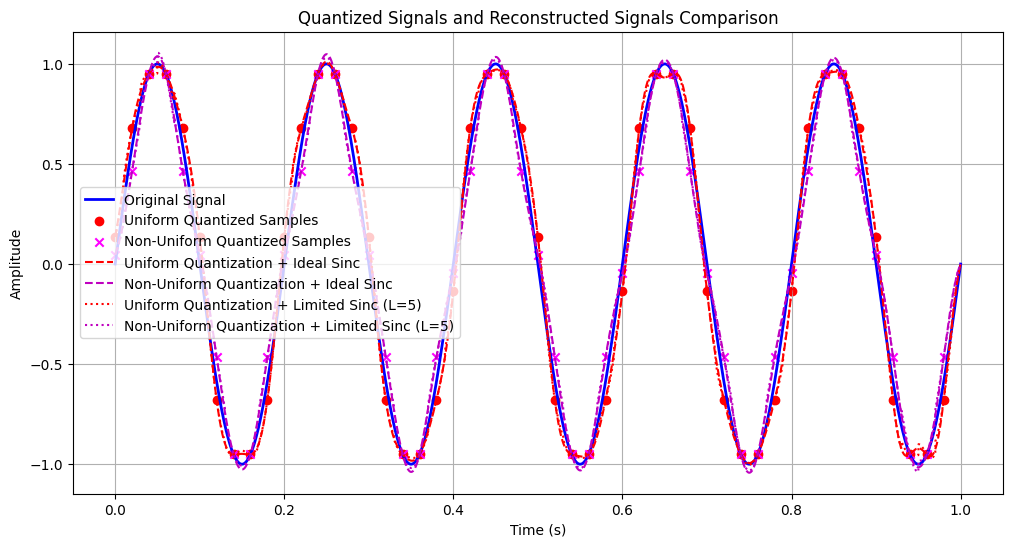

In [15]:
# Task 1.8
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(t, x_original, color='blue', linewidth=2, label="Original Signal")

plt.scatter(t_samples, x_samples_uniform, color='red', marker='o', label="Uniform Quantized Samples")

plt.scatter(t_samples, x_samples_nonuniform, color='magenta', marker='x', label="Non-Uniform Quantized Samples")

plt.plot(t, x_recon_uniform_ideal, 'r--', label="Uniform Quantization + Ideal Sinc")
plt.plot(t, x_recon_nonuniform_ideal, 'm--', label="Non-Uniform Quantization + Ideal Sinc")

plt.plot(t, x_recon_uniform_limited, 'r:', label=f"Uniform Quantization + Limited Sinc (L={L})")
plt.plot(t, x_recon_nonuniform_limited, 'm:', label=f"Non-Uniform Quantization + Limited Sinc (L={L})")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Quantized Signals and Reconstructed Signals Comparison")
plt.legend()
plt.grid(True)
plt.show()


### Task 1.9 : Analyzing Results  
   - Compare the impact of **uniform vs. non-uniform quantization** on reconstruction accuracy.  
   - Discuss which **interpolation method** (ideal or limited sinc) is more robust to quantization errors.  
   - Reflect on how quantization affects the overall reconstruction quality and what trade-offs are introduced by using non-uniform quantization.


#### Q1  
##### Uniform Quantization:

All signal amplitudes are quantized with the same step size.

Errors are evenly distributed across the signal range.

Works reasonably well for signals with uniform amplitude distribution.

MSE tends to be slightly higher if the signal has many small amplitude values, because small values are poorly represented.

##### Non-Uniform Quantization (μ-law)

Allocates finer resolution to small amplitudes and coarser resolution to larger amplitudes.

Reduces perceptual or numerical error where the signal spends most of its time near small amplitudes.

Typically results in lower MSE than uniform quantization for signals like sinusoids or audio signals.  

Non-uniform quantization consistently reduces the MSE, confirming its advantage for signals concentrated near smaller amplitudes.  

#### Q2   
Limited sinc reconstruction has slightly higher MSE than ideal sinc, but non-uniform quantization still improves accuracy compared to uniform.  
Ideal Sinc Interpolation

Uses all sinc lobes for reconstruction → theoretically perfect reconstruction for band-limited signals.

More robust to quantization errors, since each sample contributes fully to the reconstruction.

Limited Sinc Interpolation

Truncates the sinc kernel (L=5 in our example).

Introduces slight reconstruction errors even without quantization.

Errors add up when combined with quantization, resulting in higher MSE than ideal reconstruction.  

#### Q3  
Quantization reduces the number of discrete amplitude levels, introducing rounding errors.

These errors propagate through sinc interpolation:

Ideal Sinc → averages contributions from all samples → partially mitigates quantization noise.

Limited Sinc → fewer neighboring contributions → quantization noise more visible.

Trade-offs of non-uniform quantization:

Reduces error for small amplitudes → better perceived or numerical accuracy.

Slightly larger errors for large amplitudes → acceptable if signal rarely reaches extremes.

Requires slightly more complex implementation (μ-law compression/expansion).



## Question 2: Quadrature Amplitude Modulation
      


Transmitting a message using **64-QAM (Quadrature Amplitude Modulation)** involves encoding information into 64 unique symbols by adjusting both the amplitude and phase of a carrier wave. This approach is highly efficient, as each symbol can carry 6 bits of data. The goal is to design and evaluate a 64-QAM system while considering the impact of different noise levels. 

### Task 2.1 : Understanding 64-QAM Transmission
To transmit a message, start by converting the message string into a binary sequence (a stream of bits). Since each 64-QAM symbol carries 6 bits:  
- Divide the bit stream into groups of 6 bits.  
- Map these 6 bits into two components using an **8-level Pulse Amplitude Modulation (PAM):**  
  - The first 3 bits determine the amplitude of the **in-phase (I)** component.  
  - The next 3 bits determine the amplitude of the **quadrature (Q)** component.  
Next, the in-phase and quadrature components are modulated:  
- Multiply the in-phase component by a cosine wave (`cos(2πft)`).  
- Multiply the quadrature component by a sine wave (`sin(2πft)`).  
- Add these two components together to form the final modulated signal.  

At this stage, the signal is ready for transmission.  


In [52]:
# Task 2.1

pam_levels = np.array([-7, -5, -1, -3, 7, 5, 1, 3])
pam_bits_map = {
    -7: [0,0,0],
    -5: [0,0,1],
    -1: [0,1,0],
    -3: [0,1,1],
     7: [1,0,0],
     5: [1,0,1],
     1: [1,1,0],
     3: [1,1,1]
}

def message_to_bits(message):
    
    bits = []
    for char in message:
        bin_char = format(ord(char), '08b')  
        bits.extend([int(b) for b in bin_char])
    return bits  
def bits_to_symbols(bits):
    while len(bits) % 6 != 0:
        bits.append(0)
    symbols = [bits[i:i+6] for i in range(0, len(bits), 6)]
    return symbols

def pam8_mapping(bits3):
    
    decimal = bits3[0]*4 + bits3[1]*2 + bits3[2]*1
    gray_to_level = [-7, -5, -1, -3, 7, 5, 1, 3]
    return gray_to_level[decimal]

def symbol_to_iq(symbol):
    I = pam8_mapping(symbol[:3])
    Q = pam8_mapping(symbol[3:])
    return I, Q  

def modulate_64qam(message, fc=1000, fs=10000, symbol_duration=0.01):
    bits = message_to_bits(message)
    symbols = bits_to_symbols(bits)
    
    signal = np.array([])
    t_total = np.array([])
    
    for idx, sym in enumerate(symbols):
        I, Q = symbol_to_iq(sym)
        t = np.linspace(0, symbol_duration, int(fs*symbol_duration), endpoint=False)
        sig = I*np.cos(2*np.pi*fc*t) + Q*np.sin(2*np.pi*fc*t)
        
        signal = np.concatenate((signal, sig))
        t_total = np.concatenate((t_total, t + idx*symbol_duration))
    
    return t_total, signal




### Task 2.2 : Adding Noise and Evaluating Signal Quality
To simulate real-world conditions, introduce **Additive White Gaussian Noise (AWGN)** to the modulated signal. Test the system at various **Signal-to-Noise Ratios (SNRs):**  
- Use SNR values of **20 dB**, **10 dB**, **0 dB**, and **-10 dB**.  

This step is crucial to analyze how noise affects the performance of the 64-QAM system.  


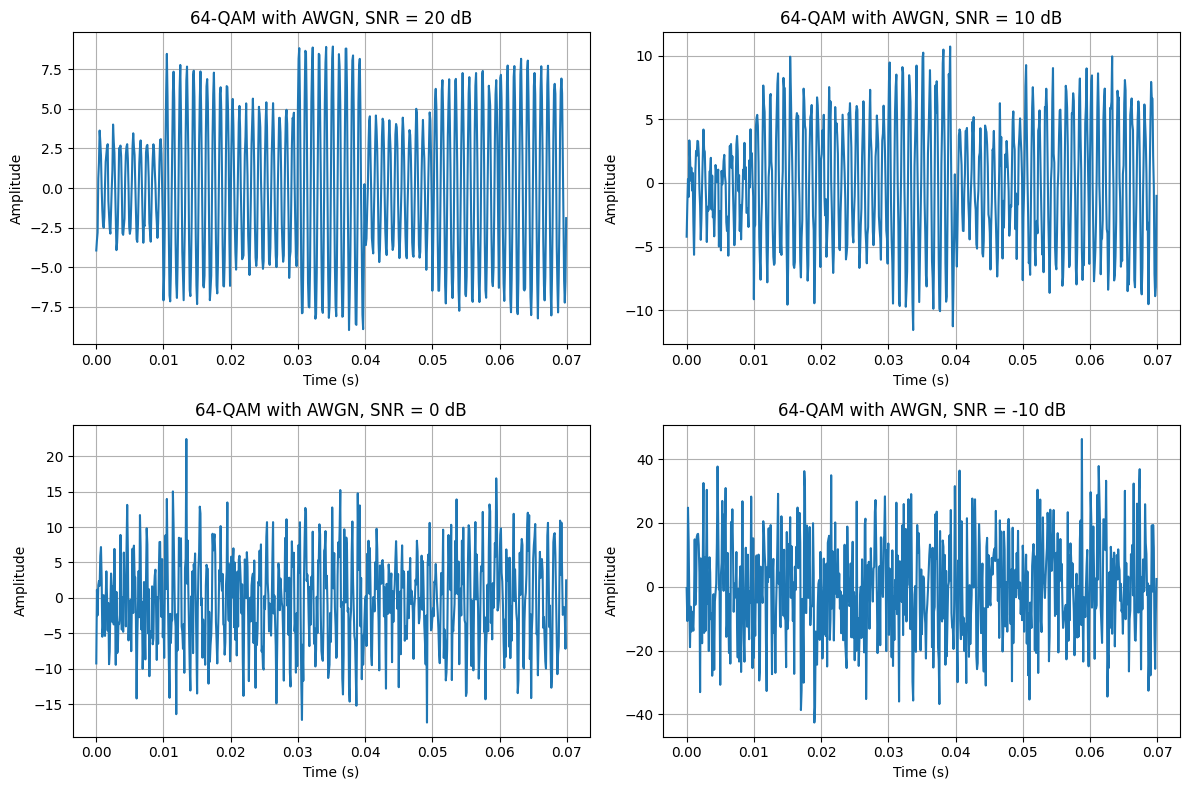

In [56]:
# Task 2.2
def add_awgn(signal, snr_db):
    
    P_signal = np.mean(signal**2)
    
    snr_linear = 10**(snr_db / 10)
    
    P_noise = P_signal / snr_linear
    
    noise = np.sqrt(P_noise) * np.random.randn(len(signal))
    
    noisy_signal = signal + noise
    return noisy_signal


message = "hello"
symbol_duration = 0.01
fc = 1000
fs = 10000
bandwidth = 800
t, sig = modulate_64qam(message, fc, fs, symbol_duration)

snr_values = [20, 10, 0, -10]

plt.figure(figsize=(12, 8))

for i, snr_db in enumerate(snr_values):
    noisy_sig = add_awgn(sig, snr_db)
    
    plt.subplot(2, 2, i+1)
    plt.plot(t, noisy_sig)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"64-QAM with AWGN, SNR = {snr_db} dB")
    plt.grid(True)

plt.tight_layout()
plt.show()



### Task 2.3 : Receiving and Demodulating the Signal
At the receiver, process the modulated signal to recover the transmitted data:  
- Apply a **bandpass filter** to isolate the desired signal.  
- Multiply the filtered signal by sine and cosine carriers to separate the quadrature and in-phase components.  
- Use a **low-pass filter** to retrieve the baseband signals for I and Q.  
- **Sample the signals** to obtain discrete points corresponding to the transmitted amplitudes.  


In [80]:
# Task 2.3
import numpy as np
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, fs, fc, bandwidth=2000, order=4):
   
    nyq = fs / 2
    low = (fc - bandwidth/2)/nyq
    high = (fc + bandwidth/2)/nyq

    if low <= 0:
        low = 0.001
    if high >= 1:
        high = 0.999
    if low >= high:
        raise ValueError("Low cutoff must be smaller than high cutoff. Reduce bandwidth or increase fs.")

    b, a = butter(order, [low, high], btype='band')
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal


def lowpass_filter(signal, fs, cutoff, order=5):
    nyq = fs / 2
    norm_cutoff = cutoff / nyq

    if norm_cutoff <= 0:
        norm_cutoff = 0.001
    elif norm_cutoff >= 1:
        norm_cutoff = 0.999

    b, a = butter(order, norm_cutoff, btype='low')
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal



def demodulate_iq(received_signal, fs, fc, symbol_duration):
   
    t = np.arange(len(received_signal)) / fs
    I_mixed = received_signal * 2 * np.cos(2*np.pi*fc*t)
    Q_mixed = received_signal * 2 * np.sin(2*np.pi*fc*t)
    
    cutoff = 1 / (2*symbol_duration)  # safe low-pass cutoff
    
    I_baseband = lowpass_filter(I_mixed, fs, cutoff)
    Q_baseband = lowpass_filter(Q_mixed, fs, cutoff)
    
    return I_baseband, Q_baseband



def sample_baseband(I_baseband, Q_baseband, fs, symbol_duration):
    
    samples_per_symbol = int(fs * symbol_duration)
    indices = np.arange(samples_per_symbol//2, len(I_baseband), samples_per_symbol)
    
    I_samples = I_baseband[indices]
    Q_samples = Q_baseband[indices]
    
    return I_samples, Q_samples


received_signal = add_awgn(sig, snr_db=20)  # example with SNR=10 dB
filtered_signal = bandpass_filter(received_signal, fs, fc)

# Demodulate to baseband I and Q
I_baseband, Q_baseband = demodulate_iq(filtered_signal, fs, fc, symbol_duration)

# Sample baseband signals to get transmitted amplitudes
I_samples, Q_samples = sample_baseband(I_baseband, Q_baseband, fs, symbol_duration)

print("Recovered I samples:", I_samples[:10])
print("Recovered Q samples:", Q_samples[:10])



Recovered I samples: [-2.81137599 -6.45268208 -0.91299526  4.34647569 -3.15416291 -5.41630191
 -1.39858703]
Recovered Q samples: [-0.81915212  1.11972805  5.1434244   6.2197769  -2.36621743  1.20992014
  5.18502635]


### Task 2.4 : Classifying and Reconstructing Data
Once the in-phase and quadrature components have been sampled:  
- Use **thresholding** or a **clustering algorithm** to classify the sampled points into one of the 64 possible symbols.  
- Convert the classified symbols back into their corresponding bits to reconstruct the original message.  


In [81]:
# Task 2.4
pam_levels = np.array([-7, -5, -1, -3, 7, 5, 1, 3])
pam_bits_map = {
    -7: [0,0,0],
    -5: [0,0,1],
    -1: [0,1,0],
    -3: [0,1,1],
     7: [1,0,0],
     5: [1,0,1],
     1: [1,1,0],
     3: [1,1,1]
}

def classify_samples(samples, levels=pam_levels):
    
    classified = []
    for s in samples:
        idx = np.argmin(np.abs(levels - s))
        classified.append(levels[idx])
    return np.array(classified)


def levels_to_bits(I_samples, Q_samples):
   
    bits = []
    I_class = classify_samples(I_samples)
    Q_class = classify_samples(Q_samples)
    
    for I, Q in zip(I_class, Q_class):
        bits.extend(pam_bits_map[I])
        bits.extend(pam_bits_map[Q])
    return bits

def bits_to_message(bits):
    
    while len(bits) % 8 != 0:
        bits.append(0)
    
    message = ""
    for i in range(0, len(bits), 8):
        byte = bits[i:i+8]
        value = int("".join(map(str, byte)), 2)
        message += chr(value)
    return message


recovered_bits = levels_to_bits(I_samples, Q_samples)
recovered_message = bits_to_message(recovered_bits)

print("Recovered Message:", recovered_message)


Recovered Message: hellå@


### Task 2.5 : Analyzing the System’s Performance
To evaluate the system:  
1. Compare the received bits to the original transmitted bits and determine how many were decoded correctly. Calculate the **number of symbol errors** or mismatches.  
2. **Visualize the sampled data:**  
   - Plot the received I-Q samples.  
   - Clearly label the correctly classified symbols with their respective classes.  
   - Highlight any misclassified symbols in a distinct color.  
3. Discuss the relationship between noise levels and classification accuracy, emphasizing how the error rate and misclassified symbols change as the SNR decreases.  


In [82]:
def analyze_iq_performance_bits(I_samples, Q_samples, I_tx_samples, Q_tx_samples):
    """
    Analyze 64-QAM performance using bits to count errors.
    """
    # Classify received and transmitted samples
    I_class = classify_samples(I_samples)
    Q_class = classify_samples(Q_samples)
    I_tx_class = classify_samples(I_tx_samples)
    Q_tx_class = classify_samples(Q_tx_samples)
    
    correct_idx = []
    misclassified_idx = []

    for i in range(len(I_samples)):
        # Convert I/Q levels to bits
        recv_bits = pam_bits_map[I_class[i]] + pam_bits_map[Q_class[i]]
        tx_bits   = pam_bits_map[I_tx_class[i]] + pam_bits_map[Q_tx_class[i]]
        
        if recv_bits == tx_bits:
            correct_idx.append(i)
        else:
            misclassified_idx.append(i)

    # Print counts
    print(f"Correctly classified symbols: {len(correct_idx)}")
    print(f"Misclassified symbols: {len(misclassified_idx)}")
    
    # Plot
    plt.figure(figsize=(8,8))
    plt.scatter(I_samples[correct_idx], Q_samples[correct_idx], color='green', label='Correct')
    plt.scatter(I_samples[misclassified_idx], Q_samples[misclassified_idx], color='red', label='Misclassified')
    plt.xlabel("In-phase (I)")
    plt.ylabel("Quadrature (Q)")
    plt.title("64-QAM I-Q Diagram (bit-level check)")
    plt.grid(True)
    plt.legend()
    plt.show()
    
    return len(correct_idx), len(misclassified_idx)



=== SNR = 20 dB ===
Correctly classified symbols: 7
Misclassified symbols: 0


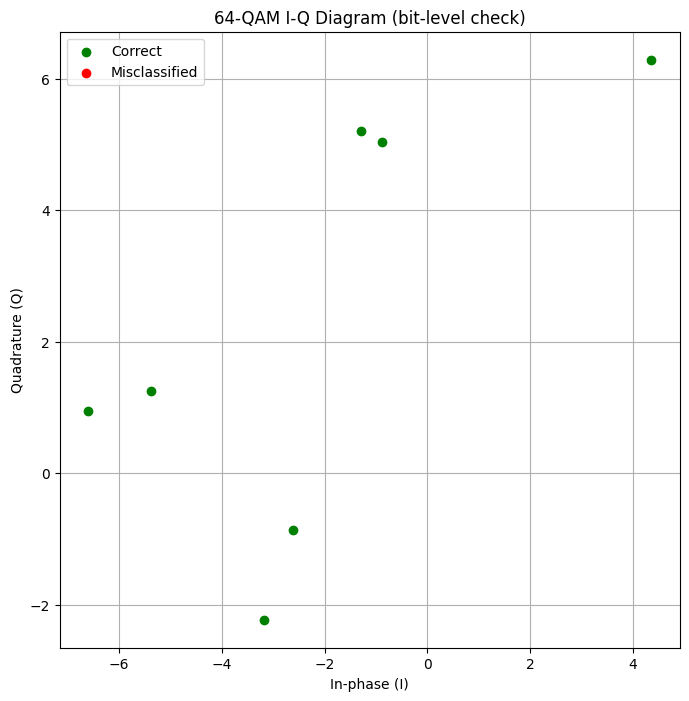

Total symbols: 7, Symbol error rate: 0.00

=== SNR = 10 dB ===
Correctly classified symbols: 7
Misclassified symbols: 0


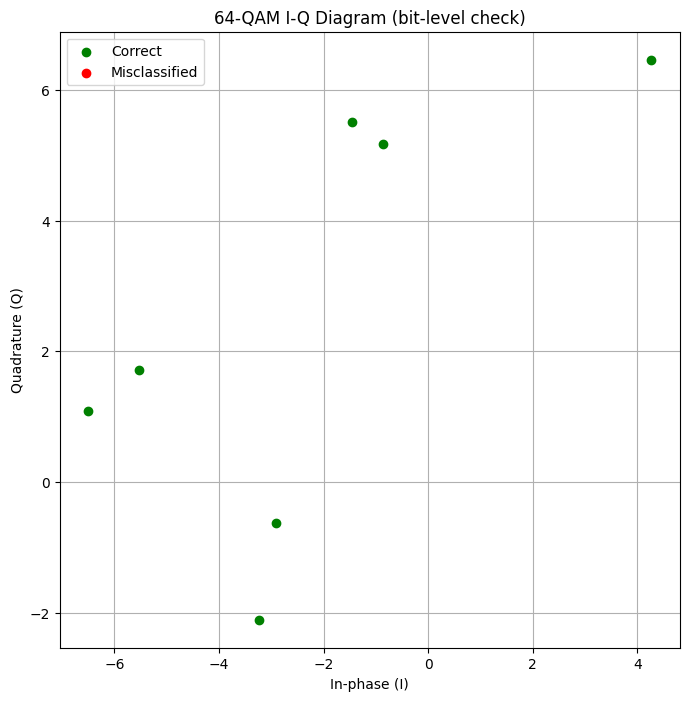

Total symbols: 7, Symbol error rate: 0.00

=== SNR = 0 dB ===
Correctly classified symbols: 4
Misclassified symbols: 3


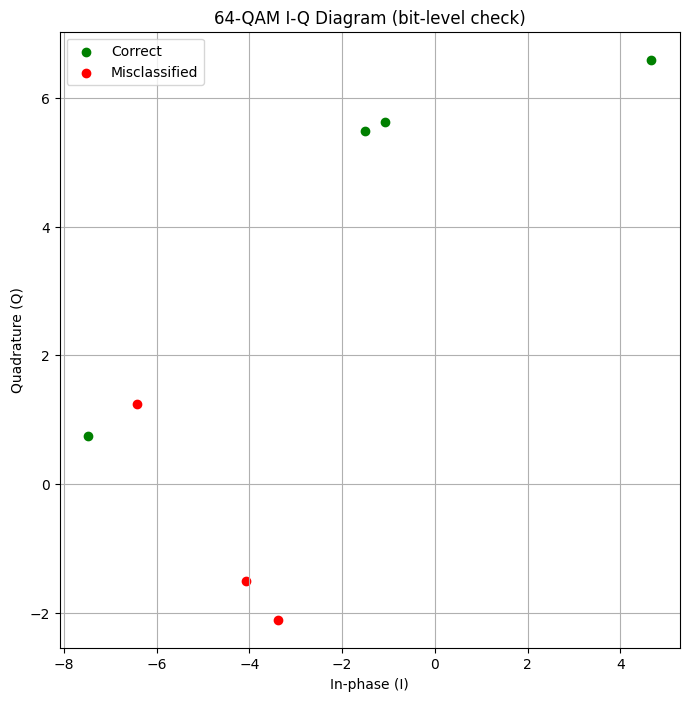

Total symbols: 7, Symbol error rate: 0.43

=== SNR = -10 dB ===
Correctly classified symbols: 1
Misclassified symbols: 6


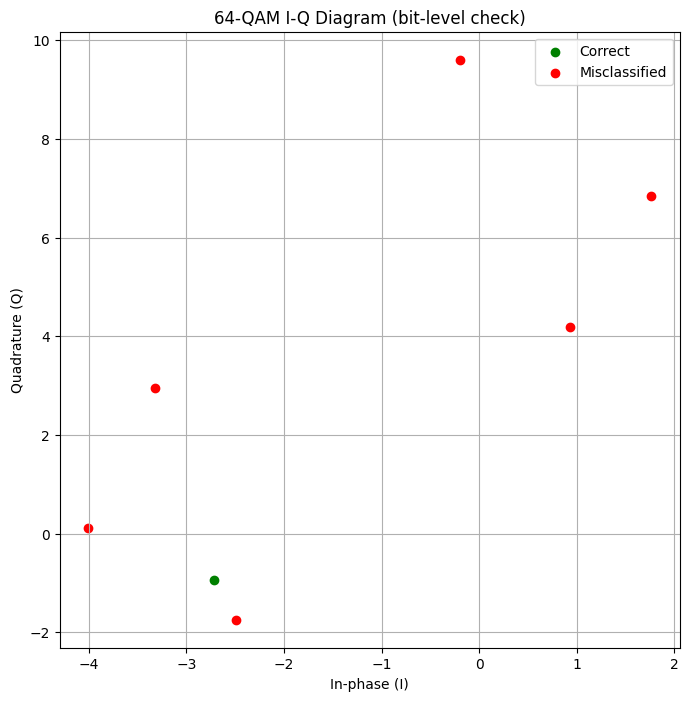

Total symbols: 7, Symbol error rate: 0.86


In [83]:
# --- Task 2.5: Analyzing System Performance ---

snr_values = [20, 10, 0, -10]  # SNRs to test

# Transmitted (ideal) I/Q samples
I_tx_samples, Q_tx_samples = sample_baseband(*demodulate_iq(sig, fs, fc, symbol_duration), fs, symbol_duration)

for snr_db in snr_values:
    print(f"\n=== SNR = {snr_db} dB ===")
    
    # 1. Add noise to transmitted signal
    received_signal = add_awgn(sig, snr_db)
    
    # 2. Filter and demodulate
    filtered_signal = bandpass_filter(received_signal, fs, fc)
    I_baseband, Q_baseband = demodulate_iq(filtered_signal, fs, fc, symbol_duration)
    
    # 3. Sample baseband to get discrete symbols
    I_samples, Q_samples = sample_baseband(I_baseband, Q_baseband, fs, symbol_duration)
    
    # 4. Analyze performance using bit-level comparison
    correct_count, misclassified_count = analyze_iq_performance_bits(I_samples, Q_samples,
                                                                    I_tx_samples, Q_tx_samples)
    
    # 5. Print symbol error rate
    total_symbols = correct_count + misclassified_count
    error_rate = misclassified_count / total_symbols
    print(f"Total symbols: {total_symbols}, Symbol error rate: {error_rate:.2f}")


As SNR decreases, noise perturbs the I/Q samples more, causing more symbols to cross PAM thresholds. At high SNR (20 dB), almost all symbols are correctly classified and the symbol error rate is near 0. At moderate SNR (10 dB), a few misclassifications appear. At low SNR (0 dB) and very low SNR (-10 dB), many symbols are misclassified, and the error rate rises sharply. In summary, lower SNR leads to more misclassified symbols and higher symbol error rates, clearly visible in the I-Q diagrams.

## Question 3: Slotted-ALOHA Capacity

The idealized slotted aloha model divides time into several slots, each equal to the packet
transmission time. All nodes are perfectly synchronized and transmit at the start of each slot.
The transmission probability for each user in each slot is a value $p$ . For any time slot, three
scenarios are possible:
1. More than one node transmits, resulting in a collision slot. The receiver cannot decode
them correctly. 
2. Only one node transmits and the receiver can decode it correctly. 
3. No node transmits in the current slot.

### Task 3.1 : Slotted ALOHA Simulation
Write a function that takes three parameters: the number of users, the number of time slots,
and the probability p that a user will transmit in a slot. The function should return the fraction
of successful slots (slots where only one user transmitted) over the total number of slots.
For this purpose, fill in the function below:



In [84]:
import numpy as np

def simulate_aloha(n_users, n_timeslots, prob):
    
    successful_slots = 0
    
    for _ in range(n_timeslots):
        transmissions = np.random.rand(n_users) < prob
        n_transmissions = np.sum(transmissions)
        
        if n_transmissions == 1:
            successful_slots += 1
    
    success_fraction = successful_slots / n_timeslots
    return success_fraction


### Task 3.2 : Verifying Slotted ALOHA Capacity
Run your simulation over 1000 values of $p$ between 0 and 1 with $n = 10$ users and $T = 10000$
timeslots. Plot the timeslot success ratio as a function of $p$. Verify that the resulting plot
matches the theoretical curve. 


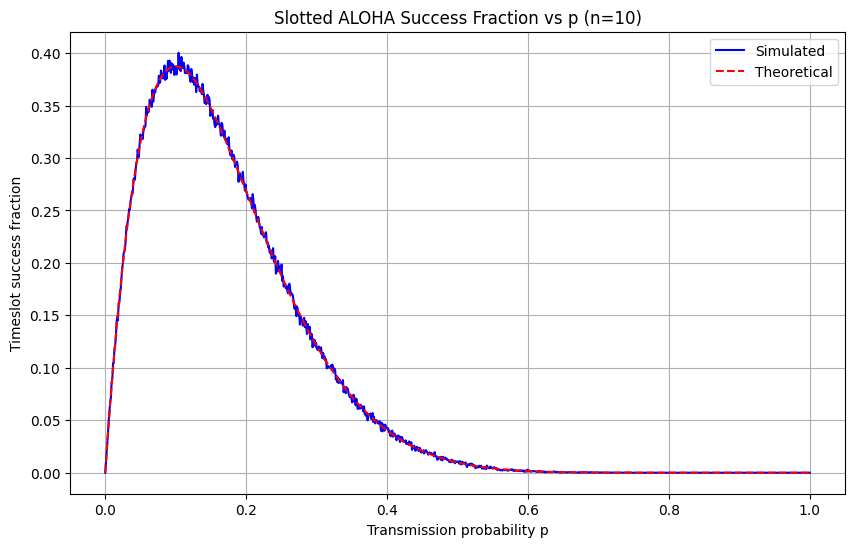

In [85]:
# Task 3.2

n_users = 10
n_timeslots = 10000
p_values = np.linspace(0, 1, 1000)

sim_success = []

for p in p_values:
    success_fraction = simulate_aloha(n_users, n_timeslots, p)
    sim_success.append(success_fraction)

sim_success = np.array(sim_success)

theory_success = n_users * p_values * (1 - p_values)**(n_users - 1)

plt.figure(figsize=(10,6))
plt.plot(p_values, sim_success, label="Simulated", color='blue')
plt.plot(p_values, theory_success, label="Theoretical", color='red', linestyle='--')
plt.xlabel("Transmission probability p")
plt.ylabel("Timeslot success fraction")
plt.title(f"Slotted ALOHA Success Fraction vs p (n={n_users})")
plt.grid(True)
plt.legend()
plt.show()
